# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Exercise 3 — Logistic Regression: Predicting Which Product a Customer Will Buy

**Scenario:** An online retailer wants to predict **which product a customer is most likely to
purchase**, based on customer attributes (in the style of the DATAtab / numiqo "logistic
regression" marketing example). Since the target has more than two possible outcomes (multiple
products), this is a **multinomial logistic regression** problem — a direct extension of binary
logistic regression to more than two classes.

**Goal:** Predict `product_purchased` (categorical: Product A / Product B / Product C) from
customer features.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Build a representative dataset

In [2]:
def generate_retail_data(n=450, seed=42):
    rng = np.random.default_rng(seed)

    age = rng.integers(18, 70, n)
    income = rng.normal(55000, 18000, n).clip(15000, 150000)
    gender = rng.choice(["Male", "Female"], size=n)
    time_on_site_min = rng.gamma(2.0, 4.0, n).clip(0.5, 60)
    past_purchases = rng.poisson(3, n)

    # Latent "utility" scores for each product (multinomial data-generating process)
    # Product A: budget item, appeals to younger / lower-income / high past-purchase browsers
    # Product B: mid-range, broadly appealing, more time on site
    # Product C: premium item, appeals to older / higher-income customers
    util_A = 0.5 - 0.03 * (age - 35) - 0.00002 * (income - 55000) + 0.15 * past_purchases
    util_B = 0.3 + 0.05 * time_on_site_min - 0.00001 * (income - 55000)
    util_C = -0.5 + 0.04 * (age - 35) + 0.00004 * (income - 55000)

    utils = np.vstack([util_A, util_B, util_C]).T
    utils += rng.gumbel(0, 1, utils.shape)  # softmax-consistent noise
    product_idx = utils.argmax(axis=1)
    product_purchased = np.array(["Product A", "Product B", "Product C"])[product_idx]

    df = pd.DataFrame({
        "age": age,
        "income": income.round(0).astype(int),
        "gender": gender,
        "time_on_site_min": time_on_site_min.round(1),
        "past_purchases": past_purchases,
        "product_purchased": product_purchased,
    })
    return df


df = generate_retail_data(450, seed=RANDOM_STATE)
print("Rows:", len(df))
print(df["product_purchased"].value_counts())
df.head()


Rows: 450
product_purchased
Product B    176
Product A    170
Product C    104
Name: count, dtype: int64


,age,income,gender,time_on_site_min,past_purchases,product_purchased
0,22,42473,Female,1.2,2,Product B
1,58,50971,Female,4.2,3,Product C
2,52,59365,Male,6.9,6,Product A
3,40,58178,Female,13.7,2,Product A
4,40,35481,Female,3.1,7,Product B


## 2. Explore the data

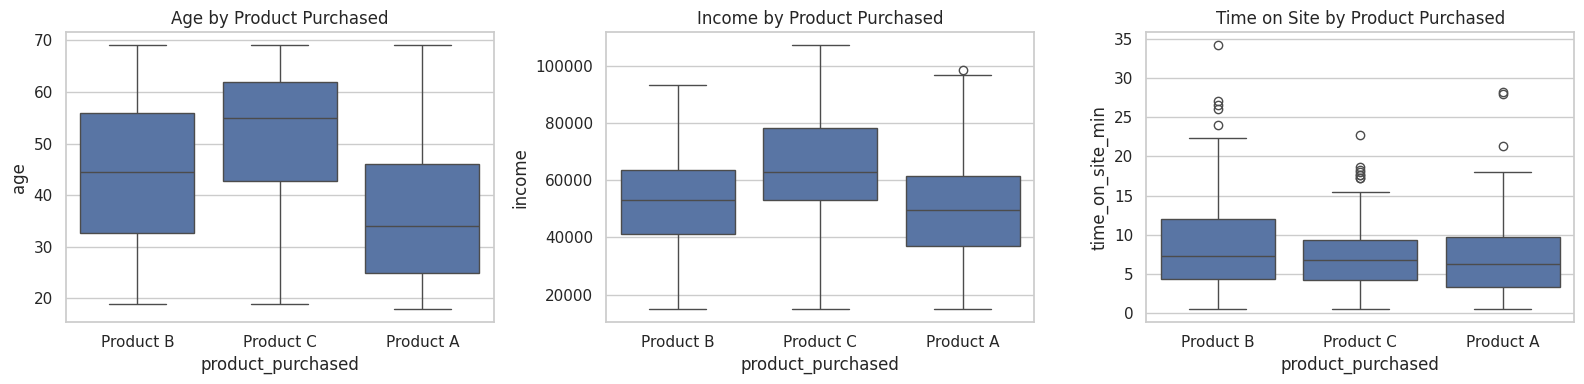

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df, x="product_purchased", y="age", ax=axes[0])
axes[0].set_title("Age by Product Purchased")

sns.boxplot(data=df, x="product_purchased", y="income", ax=axes[1])
axes[1].set_title("Income by Product Purchased")

sns.boxplot(data=df, x="product_purchased", y="time_on_site_min", ax=axes[2])
axes[2].set_title("Time on Site by Product Purchased")

plt.tight_layout()
plt.show()


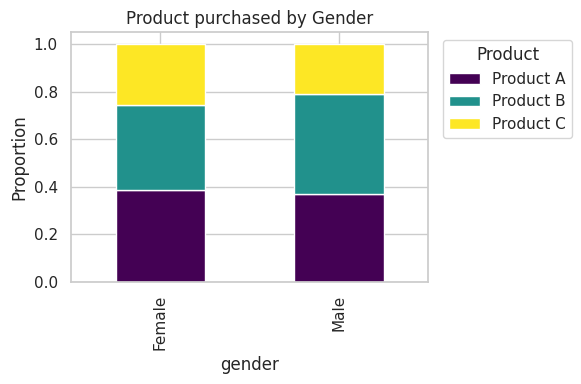

In [4]:
ct = pd.crosstab(df["gender"], df["product_purchased"], normalize="index")
ct.plot(kind="bar", stacked=True, figsize=(6, 4), colormap="viridis")
plt.ylabel("Proportion")
plt.title("Product purchased by Gender")
plt.legend(title="Product", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 3. Encode features and fit a multinomial logistic regression

`LogisticRegression` in scikit-learn natively supports multi-class targets: with more than two
classes it fits a **multinomial** model by default (softmax over classes) using cross-entropy loss.


In [5]:
df_enc = df.copy()
df_enc["gender_male"] = (df_enc["gender"] == "Male").astype(int)

feature_cols = ["age", "income", "gender_male", "time_on_site_min", "past_purchases"]
X = df_enc[feature_cols]

le = LabelEncoder()
y = le.fit_transform(df_enc["product_purchased"])
print("Classes:", list(le.classes_))


Classes: ['Product A', 'Product B', 'Product C']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.487

              precision    recall  f1-score   support

   Product A       0.60      0.58      0.59        43
   Product B       0.43      0.43      0.43        44
   Product C       0.41      0.42      0.42        26

    accuracy                           0.49       113
   macro avg       0.48      0.48      0.48       113
weighted avg       0.49      0.49      0.49       113



## 4. Confusion matrix and coefficients per class

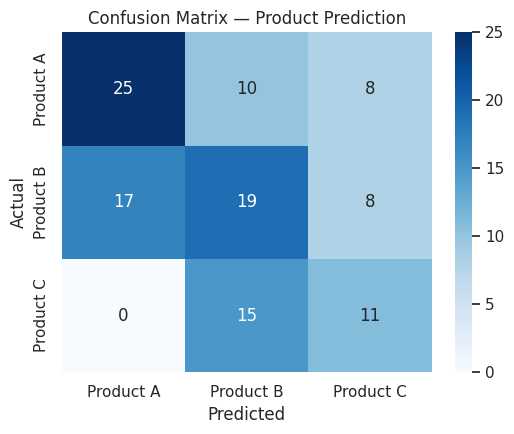

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Product Prediction")
plt.tight_layout()
plt.show()


In [8]:
coef_df = pd.DataFrame(clf.coef_, columns=feature_cols, index=le.classes_)
coef_df


,age,income,gender_male,time_on_site_min,past_purchases
Product A,-0.607351,-0.509694,-0.042383,-0.047934,0.178760
Product B,0.028538,-0.143677,0.139953,0.127235,-0.105766
Product C,0.578812,0.653371,-0.097570,-0.079302,-0.072994


**Interpretation:** each row shows how that feature (in standardized units) pushes the
model's preference toward that product class relative to the others — e.g. a positive
`past_purchases` coefficient for Product A means frequent past buyers are relatively more likely to
choose Product A, holding the other features constant.


## 5. Predict the most likely product for a new customer

In [9]:
new_customer = pd.DataFrame({
    "age": [29],
    "income": [42000],
    "gender_male": [0],
    "time_on_site_min": [12.5],
    "past_purchases": [5],
})

new_customer_scaled = scaler.transform(new_customer[feature_cols])
probs = clf.predict_proba(new_customer_scaled)[0]
pred_class = le.classes_[probs.argmax()]

for cls, p in zip(le.classes_, probs):
    print(f"  P({cls}) = {p:.1%}")
print()
print(f"Most likely purchase: {pred_class}")


  P(Product A) = 69.7%
  P(Product B) = 26.1%
  P(Product C) = 4.1%

Most likely purchase: Product A
